# First trial

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import time

t1 = time.perf_counter()

In [3]:
# Cell 1: Imports and Setup
import sys
import os
import time
import pickle

# import warnings
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Suppress warnings
# warnings.filterwarnings('ignore')

# Add src to path
sys.path.append("..")

# Import your implementations
from src.trees.boosting.adaboost_scale import AdaBoostClassifier
from src.trees.boosting.gradient_boosting import FastBinaryGradientBoosting

# Import data loaders
from src.utils.preprocessing import (
    load_breast_cancer_data,
    load_adult_income_data,
    load_covertype_data,
    load_mnist_data,
)

# Set style
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")
%matplotlib inline

print(" Imports loaded!")

 Imports loaded!


In [4]:
# Cell 2: Configuration (Updated for Full Resolution)
CONFIG = {
    # Dataset sampling
    "covertype_sample_size": 600_000,
    "mnist_sample_size": 80_000,
    # Experiment parameters
    "test_size": 0.2,
    "random_state": 42,
    # Model parameters
    "learning_rate": 0.1,
    "max_depth": 3,
    "min_samples_split": 2,
    "reg_lambda": 1.0,
    "subsample": 1.0,
    "max_features": "sqrt",
    # Scaling experiment - FULL RESOLUTION
    "n_estimators_min": 1,
    "n_estimators_max": 200,
    "n_estimators_step": 1,  # ← CHANGED from 10 to 1
    "output_dir": "gbm_vs_adaboost_results",
}

# Add this right below your CONFIG dictionary in Cell 2:
os.makedirs(CONFIG["output_dir"], exist_ok=True)
FIGURES_DIR = os.path.join("..", "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

MODELS_DIR = os.path.join(CONFIG["output_dir"], "saved_models")
os.makedirs(MODELS_DIR, exist_ok=True)

# Generate n_estimators list: [1, 2, 3, 4, 5, ..., 100]
N_ESTIMATORS_LIST = list(
    range(
        CONFIG["n_estimators_min"],
        CONFIG["n_estimators_max"] + 1,
        CONFIG["n_estimators_step"],
    )
)

print("=" * 60)
print("EXPERIMENT CONFIGURATION")
print("=" * 60)
for key, value in CONFIG.items():
    print(f"  {key}: {value}")
print(f"\n  n_estimators values: {N_ESTIMATORS_LIST[:10]}...{N_ESTIMATORS_LIST[-5:]}")
print(f"  Total runs per dataset: {len(N_ESTIMATORS_LIST)}")  # Now 100!
print("=" * 60)

EXPERIMENT CONFIGURATION
  covertype_sample_size: 600000
  mnist_sample_size: 80000
  test_size: 0.2
  random_state: 42
  learning_rate: 0.1
  max_depth: 3
  min_samples_split: 2
  reg_lambda: 1.0
  subsample: 1.0
  max_features: sqrt
  n_estimators_min: 1
  n_estimators_max: 200
  n_estimators_step: 1
  output_dir: gbm_vs_adaboost_results

  n_estimators values: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]...[196, 197, 198, 199, 200]
  Total runs per dataset: 200


In [5]:
# Cell 3: Load and Binarize Datasets

print("=" * 60)
print("LOADING AND BINARIZING DATASETS")
print("=" * 60)

RANDOM_STATE = CONFIG["random_state"]

# -------- 1. LOAD DATASETS --------

# Breast Cancer (already binary)
X_bc, y_bc, _ = load_breast_cancer_data(optimize_memory=False, verbose=True)
print(f" Breast Cancer loaded: {X_bc.shape}")

# Adult Income (already binary)
X_adult, y_adult, _ = load_adult_income_data(
    drop_categorical=True, optimize_memory=False, verbose=True
)
y_adult_binary = (y_adult.str.replace(".", "", regex=False) == ">50K").astype(int)
print(f" Adult Income loaded: {X_adult.shape}")

# Covertype
X_cover, y_cover, _ = load_covertype_data(
    drop_categorical=True, optimize_memory=False, verbose=True
)
if CONFIG["covertype_sample_size"] < len(X_cover):
    sample_indices = np.random.RandomState(RANDOM_STATE).choice(
        len(X_cover), CONFIG["covertype_sample_size"], replace=False
    )
    X_cover = X_cover.iloc[sample_indices]
    y_cover = y_cover.iloc[sample_indices]
y_cover_flat = y_cover.values.ravel()
print(f" Covertype loaded: {X_cover.shape}")

# MNIST
X_mnist, y_mnist, _ = load_mnist_data(
    optimize_memory=False, verbose=True, return_numpy=False
)
if CONFIG["mnist_sample_size"] < len(X_mnist):
    sample_indices = np.random.RandomState(RANDOM_STATE).choice(
        len(X_mnist), CONFIG["mnist_sample_size"], replace=False
    )
    X_mnist = X_mnist.iloc[sample_indices]
    y_mnist = y_mnist.iloc[sample_indices]
print(f" MNIST loaded: {X_mnist.shape}")

# -------- 2. BINARIZE MULTI-CLASS DATASETS --------


def get_two_most_common_classes(y):
    """Get the two most frequent classes."""
    unique, counts = np.unique(y, return_counts=True)
    sorted_indices = np.argsort(counts)[::-1]
    return unique[sorted_indices[0]], unique[sorted_indices[1]]


def binarize_two_classes(X, y, class_pos, class_neg):
    """Keep only two classes and map to binary."""
    mask = (y == class_pos) | (y == class_neg)
    X_binary = X[mask]
    y_binary = y[mask]
    y_binary = (y_binary == class_pos).astype(int)
    return X_binary, y_binary


# Covertype
print("\n--- Binarizing Covertype ---")
class1, class2 = get_two_most_common_classes(y_cover_flat)
print(f"  Selected: {class1} -> Positive, {class2} -> Negative")
X_cover_binary, y_cover_binary = binarize_two_classes(
    X_cover, y_cover_flat, class_pos=class1, class_neg=class2
)
print(f"   Covertype binarized: {X_cover_binary.shape}")

# MNIST
print("\n--- Binarizing MNIST ---")
class1, class2 = get_two_most_common_classes(y_mnist)
print(f"  Selected: {class1} -> Positive, {class2} -> Negative")
X_mnist_binary, y_mnist_binary = binarize_two_classes(
    X_mnist.values if hasattr(X_mnist, "values") else X_mnist,
    y_mnist.values if hasattr(y_mnist, "values") else y_mnist,
    class_pos=class1,
    class_neg=class2,
)
print(f"   MNIST binarized: {X_mnist_binary.shape}")

# -------- 3. CREATE DATASETS DICTIONARY --------

datasets = {
    "Breast_Cancer": (X_bc.values, y_bc.values),
    "Adult_Income": (X_adult.values, y_adult_binary.values),
    "Covertype": (X_cover_binary, y_cover_binary),
    "MNIST": (X_mnist_binary, y_mnist_binary),
}

# -------- 4. SUMMARY --------

print("\n" + "=" * 60)
print("DATASET SUMMARY")
print("=" * 60)

for name, (X, y) in datasets.items():
    unique, counts = np.unique(y, return_counts=True)
    total = len(y)
    ratio = counts[1] / counts[0] if counts[0] > 0 else float("inf")
    balance = " Balanced" if 0.67 <= ratio <= 1.5 else " Imbalanced"
    print(f"\n{name}: {total} samples, {X.shape[1]} features, {balance}")
    print(f"  Class 0: {counts[0]} ({counts[0] / total * 100:.1f}%)")
    print(f"  Class 1: {counts[1]} ({counts[1] / total * 100:.1f}%)")

print("\n" + "=" * 60)
print(" ALL DATASETS READY!")
print("=" * 60)

LOADING AND BINARIZING DATASETS
Loaded from CSV: /Users/student/Desktop/experiment_ml_project_adaboost_scaling/data/breast_cancer.csv
 Breast Cancer loaded: (569, 30)
Loaded from CSV: /Users/student/Desktop/experiment_ml_project_adaboost_scaling/data/adult_income.csv
 Adult Income loaded: (48842, 6)
Loaded from CSV: /Users/student/Desktop/experiment_ml_project_adaboost_scaling/data/covertype.csv
 Covertype loaded: (581012, 10)
Loaded from CSV: /Users/student/Desktop/experiment_ml_project_adaboost_scaling/data/mnist.csv
 MNIST loaded: (70000, 784)

--- Binarizing Covertype ---
  Selected: 2 -> Positive, 1 -> Negative
   Covertype binarized: (495141, 10)

--- Binarizing MNIST ---
  Selected: 1 -> Positive, 7 -> Negative
   MNIST binarized: (15170, 784)

DATASET SUMMARY

Breast_Cancer: 569 samples, 30 features,  Imbalanced
  Class 0: 212 (37.3%)
  Class 1: 357 (62.7%)

Adult_Income: 48842 samples, 6 features,  Imbalanced
  Class 0: 37155 (76.1%)
  Class 1: 11687 (23.9%)

Covertype: 495141

In [6]:
np.unique(y_mnist_binary, return_counts=True)

(array([0, 1]), array([7293, 7877]))

In [7]:
def run_adaboost_experiment_optimized(X, y, dataset_name, n_estimators_list, config):
    results = []
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=config["test_size"],
        random_state=config["random_state"],
        stratify=y,
    )
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Param-aware Filename Logic
    lr_str = str(config["learning_rate"]).replace(".", "_")
    depth_str = str(config["max_depth"])
    max_n = max(n_estimators_list)
    model_path = os.path.join(
        MODELS_DIR, f"AdaBoost_{dataset_name}_lr{lr_str}_depth{depth_str}_n{max_n}.pkl"
    )

    if os.path.exists(model_path):
        print(f"   [!] Loading cached AdaBoost model: {os.path.basename(model_path)}")
        with open(model_path, "rb") as f:
            ab = pickle.load(f)
        total_train_time = 0
    else:
        print(
            f"   [!] Training new AdaBoost model: {dataset_name} (lr={config['learning_rate']}, depth={config['max_depth']})..."
        )
        start_time = time.perf_counter()
        ab = AdaBoostClassifier(
            n_estimators=max_n,
            learning_rate=config["learning_rate"],
            criterion="gini",
            random_state=config["random_state"],
        )
        ab.fit(X_train_scaled, y_train)
        total_train_time = time.perf_counter() - start_time
        with open(model_path, "wb") as f:
            pickle.dump(ab, f)

    train_stages = list(ab.staged_predict(X_train_scaled))
    test_stages = list(ab.staged_predict(X_test_scaled))

    for idx, n_est in enumerate(n_estimators_list):
        train_pred = train_stages[idx]
        test_pred = test_stages[idx]
        results.append(
            {
                "dataset": dataset_name,
                "n_estimators": n_est,
                "train_accuracy": accuracy_score(y_train, train_pred),
                "train_f1": f1_score(y_train, train_pred),
                "test_accuracy": accuracy_score(y_test, test_pred),
                "test_f1": f1_score(y_test, test_pred),
                "test_auc": None,
                "train_time": total_train_time * (n_est / max_n),
                "n_estimators_fitted": n_est,
            }
        )

    final_proba = ab.predict_proba(X_test_scaled)
    final_auc = roc_auc_score(y_test, final_proba[:, 1])
    for res in results:
        res["test_auc"] = final_auc

    final_df = pd.DataFrame(results)
    final_df.to_csv(
        os.path.join(config["output_dir"], f"adaboost_{dataset_name}_scaling_full.csv"),
        index=False,
    )
    return final_df


print("=" * 60)
print("RUNNING OPTIMIZED ADABOOST (FULL RESOLUTION)")
print("=" * 60)

adaboost_results_full = {}

for name, (X, y) in datasets.items():
    print(f"\n {name} ({X.shape[0]} samples, {X.shape[1]} features)")
    print("-" * 40)

    df = run_adaboost_experiment_optimized(X, y, name, N_ESTIMATORS_LIST, CONFIG)
    adaboost_results_full[name] = df
    print(f"   ✅ Saved to adaboost_{name}_scaling_full.csv ({len(df)} rows)")

RUNNING OPTIMIZED ADABOOST (FULL RESOLUTION)

 Breast_Cancer (569 samples, 30 features)
----------------------------------------
   [!] Training new AdaBoost model: Breast_Cancer (lr=0.1, depth=3)...
   ✅ Saved to adaboost_Breast_Cancer_scaling_full.csv (200 rows)

 Adult_Income (48842 samples, 6 features)
----------------------------------------
   [!] Training new AdaBoost model: Adult_Income (lr=0.1, depth=3)...
   ✅ Saved to adaboost_Adult_Income_scaling_full.csv (200 rows)

 Covertype (495141 samples, 10 features)
----------------------------------------
   [!] Training new AdaBoost model: Covertype (lr=0.1, depth=3)...
   ✅ Saved to adaboost_Covertype_scaling_full.csv (200 rows)

 MNIST (15170 samples, 784 features)
----------------------------------------
   [!] Training new AdaBoost model: MNIST (lr=0.1, depth=3)...
   ✅ Saved to adaboost_MNIST_scaling_full.csv (200 rows)


In [8]:
def run_gradient_boosting_experiment_optimized(
    X, y, dataset_name, n_estimators_list, config
):
    results = []
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=config["test_size"],
        random_state=config["random_state"],
        stratify=y,
    )
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Param-aware Filename Logic
    lr_str = str(config["learning_rate"]).replace(".", "_")
    depth_str = str(config["max_depth"])
    max_n = max(n_estimators_list)
    model_path = os.path.join(
        MODELS_DIR, f"GBM_{dataset_name}_lr{lr_str}_depth{depth_str}_n{max_n}.pkl"
    )

    if os.path.exists(model_path):
        print(f"   [!] Loading cached GBM model: {os.path.basename(model_path)}")
        with open(model_path, "rb") as f:
            gb = pickle.load(f)
        total_train_time = 0
    else:
        print(
            f"   [!] Training new GBM model: {dataset_name} (lr={config['learning_rate']}, depth={config['max_depth']})..."
        )
        start_time = time.perf_counter()
        gb = FastBinaryGradientBoosting(
            n_estimators=max_n,
            learning_rate=config["learning_rate"],
            max_depth=config["max_depth"],
            min_samples_split=config["min_samples_split"],
            subsample=config["subsample"],
            max_features=config["max_features"],
            reg_lambda=config["reg_lambda"],
            random_state=config["random_state"],
        )
        gb.fit(X_train_scaled, y_train)
        total_train_time = time.perf_counter() - start_time
        with open(model_path, "wb") as f:
            pickle.dump(gb, f)

    train_stages = list(gb.staged_predict(X_train_scaled))
    test_stages = list(gb.staged_predict(X_test_scaled))

    for idx, n_est in enumerate(n_estimators_list):
        train_pred = train_stages[idx]
        test_pred = test_stages[idx]
        results.append(
            {
                "dataset": dataset_name,
                "n_estimators": n_est,
                "train_accuracy": accuracy_score(y_train, train_pred),
                "train_f1": f1_score(y_train, train_pred),
                "test_accuracy": accuracy_score(y_test, test_pred),
                "test_f1": f1_score(y_test, test_pred),
                "test_auc": None,
                "train_time": total_train_time * (n_est / max_n),
                "n_estimators_fitted": n_est,
            }
        )

    final_proba = gb.predict_proba(X_test_scaled)
    final_auc = roc_auc_score(y_test, final_proba[:, 1])
    for res in results:
        res["test_auc"] = final_auc

    final_df = pd.DataFrame(results)
    final_df.to_csv(
        os.path.join(
            config["output_dir"], f"gradient_boosting_{dataset_name}_scaling_full.csv"
        ),
        index=False,
    )
    return final_df


print("=" * 60)
print("RUNNING OPTIMIZED GRADIENT BOOSTING (FULL RESOLUTION)")
print("=" * 60)

gb_results_full = {}

for name, (X, y) in datasets.items():
    print(f"\n {name} ({X.shape[0]} samples, {X.shape[1]} features)")
    print("-" * 40)

    df = run_gradient_boosting_experiment_optimized(
        X, y, name, N_ESTIMATORS_LIST, CONFIG
    )
    gb_results_full[name] = df
    print(f"   ✅ Saved to gradient_boosting_{name}_scaling_full.csv ({len(df)} rows)")

RUNNING OPTIMIZED GRADIENT BOOSTING (FULL RESOLUTION)

 Breast_Cancer (569 samples, 30 features)
----------------------------------------
   [!] Training new GBM model: Breast_Cancer (lr=0.1, depth=3)...
   ✅ Saved to gradient_boosting_Breast_Cancer_scaling_full.csv (200 rows)

 Adult_Income (48842 samples, 6 features)
----------------------------------------
   [!] Training new GBM model: Adult_Income (lr=0.1, depth=3)...
   ✅ Saved to gradient_boosting_Adult_Income_scaling_full.csv (200 rows)

 Covertype (495141 samples, 10 features)
----------------------------------------
   [!] Training new GBM model: Covertype (lr=0.1, depth=3)...
   ✅ Saved to gradient_boosting_Covertype_scaling_full.csv (200 rows)

 MNIST (15170 samples, 784 features)
----------------------------------------
   [!] Training new GBM model: MNIST (lr=0.1, depth=3)...
   ✅ Saved to gradient_boosting_MNIST_scaling_full.csv (200 rows)


In [9]:
# Cell 7: Combine and Compare Results

print("=" * 60)
print("COMBINING AND COMPARING OPTIMIZED RESULTS (FULL RESOLUTION)")
print("=" * 60)

out_dir = CONFIG["output_dir"]

# 1. Combine individual full-resolution AdaBoost files
# Look inside the folder using os.path.join
adaboost_opt_files = glob.glob(os.path.join(out_dir, "adaboost_*_scaling_full.csv"))
if adaboost_opt_files:
    adaboost_df = pd.concat(
        [pd.read_csv(f) for f in adaboost_opt_files], ignore_index=True
    )
    # Save output to the folder
    adaboost_df.to_csv(
        os.path.join(out_dir, "adaboost_scaling_results.csv"), index=False
    )
    print(
        f" Loaded and combined {len(adaboost_opt_files)} full-resolution AdaBoost files."
    )
else:
    adaboost_df = pd.DataFrame()

# 2. Combine individual full-resolution Gradient Boosting files
# Look inside the folder
gb_opt_files = glob.glob(os.path.join(out_dir, "gradient_boosting_*_scaling_full.csv"))
if gb_opt_files:
    gb_df = pd.concat([pd.read_csv(f) for f in gb_opt_files], ignore_index=True)
    # Save output to the folder
    gb_df.to_csv(
        os.path.join(out_dir, "gradient_boosting_scaling_results.csv"), index=False
    )
    print(
        f" Loaded and combined {len(gb_opt_files)} full-resolution Gradient Boosting files."
    )
else:
    gb_df = pd.DataFrame()

# 3. Process and Compare
if not adaboost_df.empty and not gb_df.empty:
    adaboost_df["model"] = "AdaBoost"
    gb_df["model"] = "Gradient Boosting"

    combined_df = pd.concat([adaboost_df, gb_df], ignore_index=True)
    # Save output to the folder
    combined_df.to_csv(
        os.path.join(out_dir, "combined_scaling_results.csv"), index=False
    )

    comparison_df = combined_df.pivot_table(
        index=["dataset", "n_estimators"],
        columns="model",
        values=["test_accuracy", "test_f1", "test_auc", "train_time"],
    ).reset_index()

    comparison_df.columns = [
        "_".join([str(c) for c in col if c]).strip() if isinstance(col, tuple) else col
        for col in comparison_df.columns.values
    ]

    comparison_df["accuracy_improvement"] = (
        comparison_df["test_accuracy_Gradient Boosting"]
        - comparison_df["test_accuracy_AdaBoost"]
    )

    # Save output to the folder
    comparison_df.to_csv(os.path.join(out_dir, "comparison_results.csv"), index=False)

    print(f"\n Combined results saved to {out_dir}/:")
    print(f"   - combined_scaling_results.csv ({len(combined_df)} rows)")
    print(f"   - comparison_results.csv ({len(comparison_df)} rows)")
else:
    print(" Missing full-resolution results files. Please run Cells 4 and 5 first.")

COMBINING AND COMPARING OPTIMIZED RESULTS (FULL RESOLUTION)
 Loaded and combined 4 full-resolution AdaBoost files.
 Loaded and combined 4 full-resolution Gradient Boosting files.

 Combined results saved to gbm_vs_adaboost_results/:
   - combined_scaling_results.csv (1600 rows)
   - comparison_results.csv (800 rows)


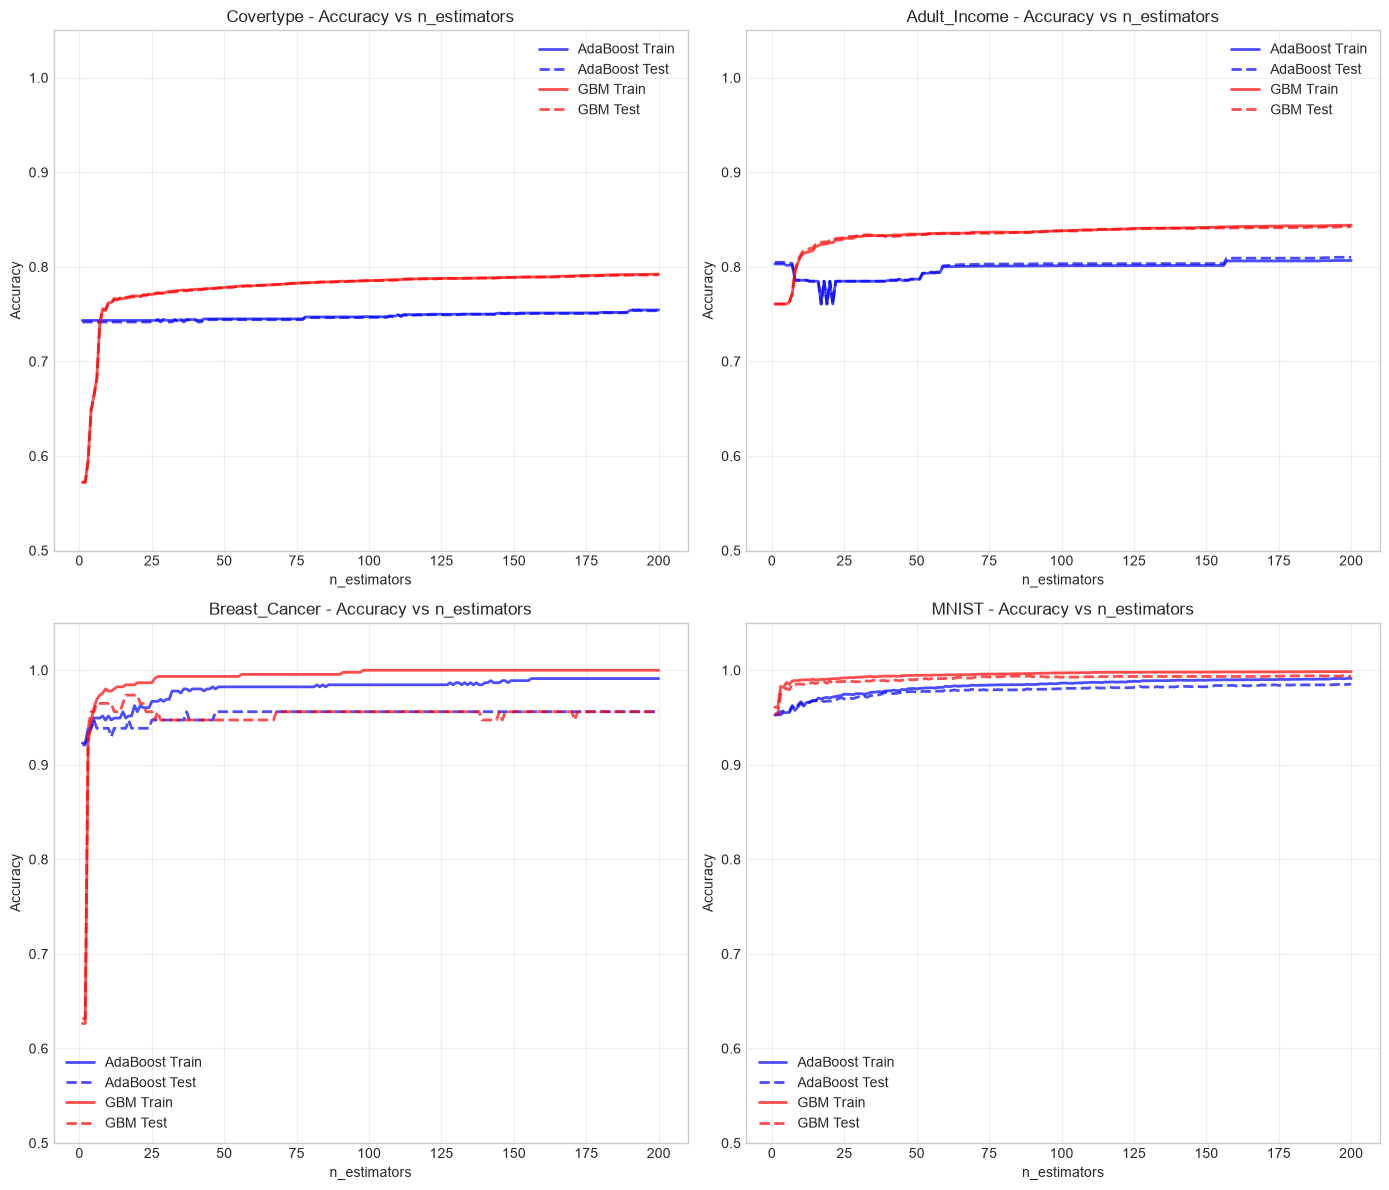

 Scaling curves saved to ../figures/scaling_curves.png


In [10]:
# Cell 8: Visualizations - Scaling Curves

if not combined_df.empty:
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))

    datasets_list = combined_df["dataset"].unique()

    for idx, dataset in enumerate(datasets_list):
        row = idx // 2
        col = idx % 2
        ax = axes[row, col]

        # Filter data
        df_subset = combined_df[combined_df["dataset"] == dataset]

        # Plot AdaBoost
        ab_data = df_subset[df_subset["model"] == "AdaBoost"]
        ax.plot(
            ab_data["n_estimators"],
            ab_data["train_accuracy"],
            "b-",
            label="AdaBoost Train",
            alpha=0.7,
            linewidth=2,
        )
        ax.plot(
            ab_data["n_estimators"],
            ab_data["test_accuracy"],
            "b--",
            label="AdaBoost Test",
            alpha=0.7,
            linewidth=2,
        )

        # Plot Gradient Boosting
        gb_data = df_subset[df_subset["model"] == "Gradient Boosting"]
        ax.plot(
            gb_data["n_estimators"],
            gb_data["train_accuracy"],
            "r-",
            label="GBM Train",
            alpha=0.7,
            linewidth=2,
        )
        ax.plot(
            gb_data["n_estimators"],
            gb_data["test_accuracy"],
            "r--",
            label="GBM Test",
            alpha=0.7,
            linewidth=2,
        )

        ax.set_xlabel("n_estimators")
        ax.set_ylabel("Accuracy")
        ax.set_title(f"{dataset} - Accuracy vs n_estimators")
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0.5, 1.05)

    plt.tight_layout()
    plt.savefig(
        os.path.join(FIGURES_DIR, "scaling_curves.png"), dpi=150, bbox_inches="tight"
    )
    plt.show()
    print(f" Scaling curves saved to {os.path.join(FIGURES_DIR, 'scaling_curves.png')}")
else:
    print(" No data to visualize. Run experiments first.")

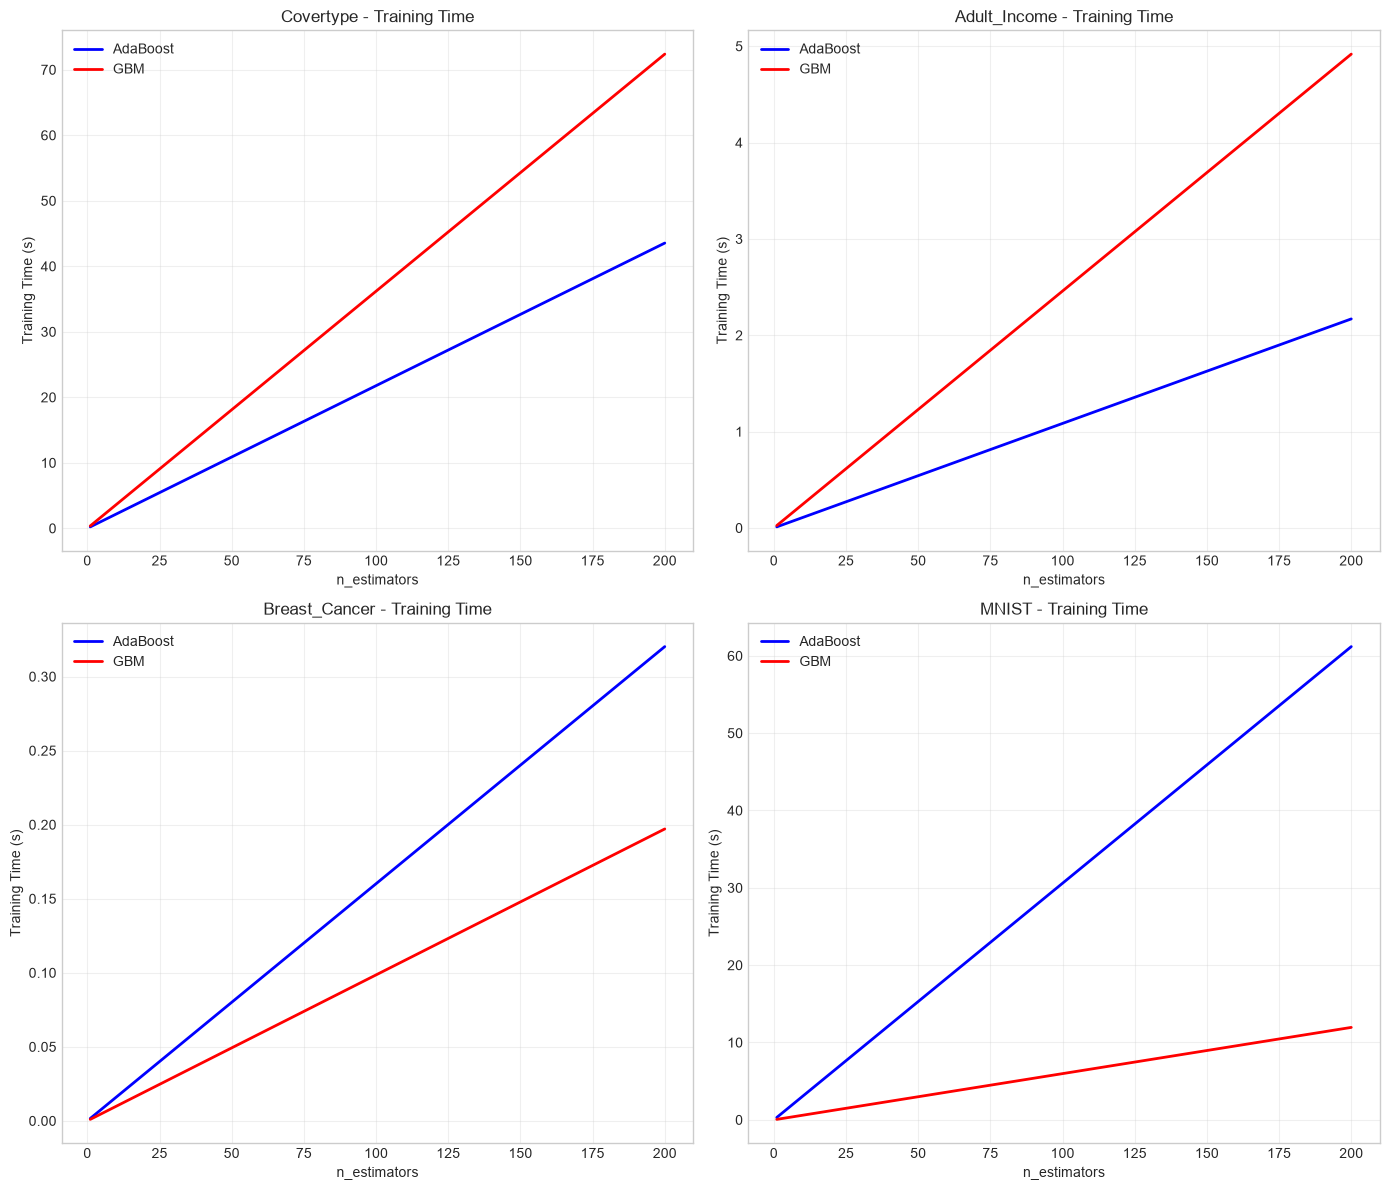

 Speed comparison saved to ../figures/speed_comparison.png


In [11]:
# Cell 9: Visualizations - Speed Comparison

if not combined_df.empty:
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))

    datasets_list = combined_df["dataset"].unique()

    for idx, dataset in enumerate(datasets_list):
        row = idx // 2
        col = idx % 2
        ax = axes[row, col]

        df_subset = combined_df[combined_df["dataset"] == dataset]

        # Plot training time
        ab_data = df_subset[df_subset["model"] == "AdaBoost"]
        gb_data = df_subset[df_subset["model"] == "Gradient Boosting"]

        ax.plot(
            ab_data["n_estimators"],
            ab_data["train_time"],
            "b-",
            label="AdaBoost",
            linewidth=2,
        )
        ax.plot(
            gb_data["n_estimators"],
            gb_data["train_time"],
            "r-",
            label="GBM",
            linewidth=2,
        )

        ax.set_xlabel("n_estimators")
        ax.set_ylabel("Training Time (s)")
        ax.set_title(f"{dataset} - Training Time")
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(
        os.path.join(FIGURES_DIR, "speed_comparison.png"), dpi=150, bbox_inches="tight"
    )
    plt.show()
    print(
        f" Speed comparison saved to {os.path.join(FIGURES_DIR, 'speed_comparison.png')}"
    )
else:
    print(" No data to visualize. Run experiments first.")

 Note: Text values omitted from heatmap cells to maintain readability at 100 columns.


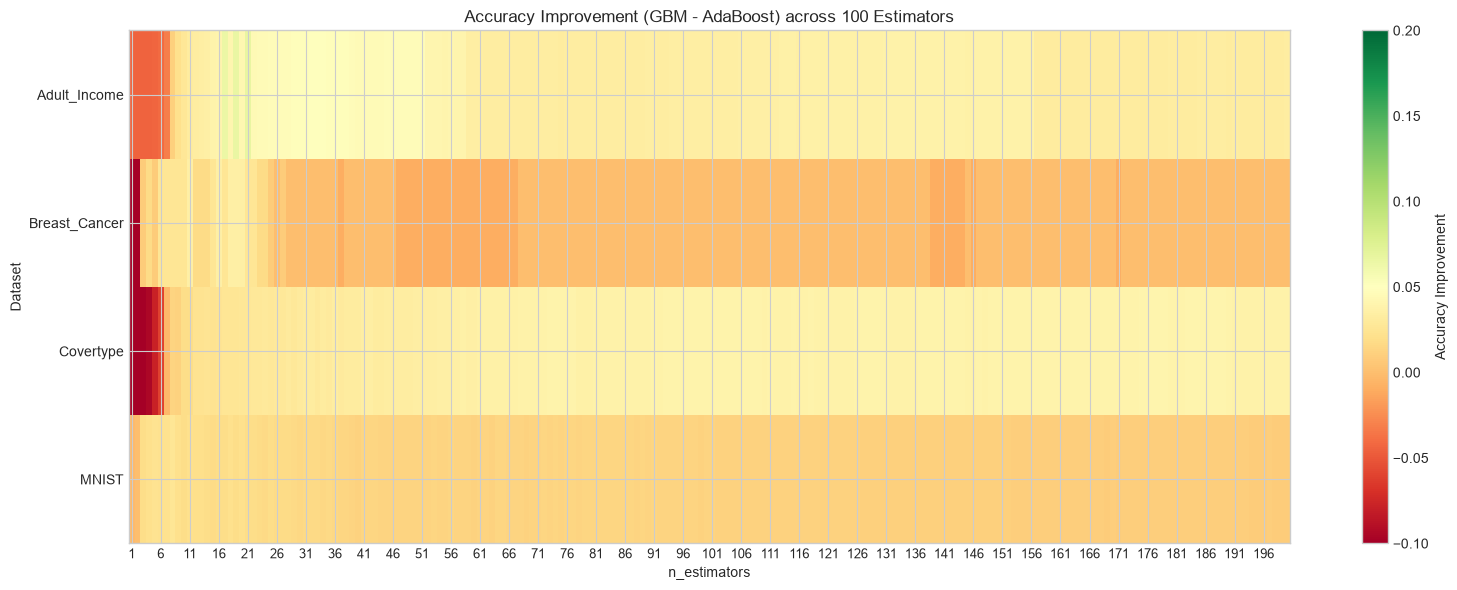

 Improvement heatmap saved to ../figures/improvement_heatmap.png


In [12]:
# Cell 10: Visualizations - Improvement Heatmap

if not comparison_df.empty:
    # Create improvement matrix
    improvement_df = comparison_df.pivot_table(
        index="dataset", columns="n_estimators", values="accuracy_improvement"
    )

    # Plot heatmap
    fig, ax = plt.subplots(figsize=(16, 6))
    im = ax.imshow(
        improvement_df.values, cmap="RdYlGn", aspect="auto", vmin=-0.1, vmax=0.2
    )

    # Adjust ticks for 100 columns so they don't overlap
    ax.set_xticks(range(0, len(improvement_df.columns), 5))  # Label every 5th estimator
    ax.set_xticklabels(improvement_df.columns[::5], rotation=0, fontsize=9)

    ax.set_yticks(range(len(improvement_df.index)))
    ax.set_yticklabels(improvement_df.index, fontsize=10)

    ax.set_xlabel("n_estimators")
    ax.set_ylabel("Dataset")
    ax.set_title("Accuracy Improvement (GBM - AdaBoost) across 100 Estimators")

    # Add colorbar
    plt.colorbar(im, ax=ax, label="Accuracy Improvement")

    # Add text overlay selectively (Only if columns < 20, otherwise visual is too dense)
    if len(improvement_df.columns) <= 20:
        for i in range(len(improvement_df.index)):
            for j in range(len(improvement_df.columns)):
                val = improvement_df.iloc[i, j]
                if not np.isnan(val):
                    color = "black" if abs(val) < 0.05 else "white"
                    ax.text(
                        j,
                        i,
                        f"{val:.2%}",
                        ha="center",
                        va="center",
                        color=color,
                        fontsize=8,
                    )
    else:
        # For high-resolution, add a helpful note
        print(
            " Note: Text values omitted from heatmap cells to maintain readability at 100 columns."
        )

    plt.tight_layout()
    plt.savefig(
        os.path.join(FIGURES_DIR, "improvement_heatmap.png"),
        dpi=150,
        bbox_inches="tight",
    )
    plt.show()
    print(
        f" Improvement heatmap saved to {os.path.join(FIGURES_DIR, 'improvement_heatmap.png')}"
    )
else:
    print(" No comparison data available. Run experiments first.")

In [13]:
# Cell 11: Summary and Conclusions

print("=" * 60)
print("FINAL SUMMARY: AdaBoost vs Gradient Boosting Scaling")
print("=" * 60)

if not comparison_df.empty:
    # Check if 'dataset' column exists
    if "dataset" not in comparison_df.columns:
        print(" 'dataset' column not found in comparison_df. Available columns:")
        print(comparison_df.columns.tolist())
    else:
        datasets_list = comparison_df["dataset"].unique()

        # Best accuracy for each model on each dataset
        print("\n BEST ACCURACY:")
        for dataset in datasets_list:
            df_subset = comparison_df[comparison_df["dataset"] == dataset]
            best_ab = df_subset["test_accuracy_AdaBoost"].max()
            best_gb = df_subset["test_accuracy_Gradient Boosting"].max()
            improvement = best_gb - best_ab
            print(f"\n  {dataset}:")
            print(f"    AdaBoost:          {best_ab:.4f}")
            print(f"    Gradient Boosting: {best_gb:.4f}")
            print(
                f"    Improvement:       {improvement:+.4f} ({improvement * 100:+.2f}%)"
            )

        # n_estimators needed to reach best
        print("\n n_estimators FOR BEST ACCURACY:")
        for dataset in datasets_list:
            df_subset = comparison_df[comparison_df["dataset"] == dataset]
            ab_best_n = df_subset.loc[
                df_subset["test_accuracy_AdaBoost"].idxmax(), "n_estimators"
            ]
            gb_best_n = df_subset.loc[
                df_subset["test_accuracy_Gradient Boosting"].idxmax(), "n_estimators"
            ]
            print(f"\n  {dataset}:")
            print(f"    AdaBoost:          {ab_best_n} estimators")
            print(f"    Gradient Boosting: {gb_best_n} estimators")

        # Speed comparison at n=50
        print("\n⚡ SPEED COMPARISON (at n=50):")
        for dataset in datasets_list:
            df_subset = comparison_df[comparison_df["dataset"] == dataset]
            df_50 = df_subset[df_subset["n_estimators"] == 51]
            if not df_50.empty:
                ab_time = df_50["train_time_AdaBoost"].values[0]
                gb_time = df_50["train_time_Gradient Boosting"].values[0]
                ratio = gb_time / ab_time if ab_time > 0 else float("inf")
                speedup = ab_time / gb_time if gb_time > 0 else 0
                print(f"\n  {dataset}:")
                print(f"    AdaBoost:          {ab_time:.4f}s")
                print(f"    Gradient Boosting: {gb_time:.4f}s")
                if gb_time > ab_time:
                    print(f"    GBM is {ratio:.2f}x slower than AdaBoost")
                else:
                    print(f"    GBM is {speedup:.2f}x faster than AdaBoost")

        # Overall conclusion
        print("\n" + "=" * 60)
        print(" OVERALL CONCLUSION")
        print("=" * 60)

        overall_best_gb = comparison_df["test_accuracy_Gradient Boosting"].mean()
        overall_best_ab = comparison_df["test_accuracy_AdaBoost"].mean()

        if overall_best_gb > overall_best_ab:
            print(" Gradient Boosting outperforms AdaBoost on average")
            print(f"   Average GBM accuracy: {overall_best_gb:.4f}")
            print(f"   Average AdaBoost accuracy: {overall_best_ab:.4f}")
            print(f"   Average improvement: {overall_best_gb - overall_best_ab:.4f}")
        else:
            print(" AdaBoost outperforms Gradient Boosting on average")
            print(f"   Average AdaBoost accuracy: {overall_best_ab:.4f}")
            print(f"   Average GBM accuracy: {overall_best_gb:.4f}")
            print(f"   Average improvement: {overall_best_ab - overall_best_gb:.4f}")

        print("\n RECOMMENDATION:")
        print("  - Use Gradient Boosting for accuracy-critical applications")
        print("  - Use AdaBoost for faster training on large datasets")
        print("  - GBM is particularly effective on high-dimensional data (MNIST)")

else:
    print(" No comparison data available. Run experiments first.")

print("\n" + "=" * 60)
print(" NOTEBOOK COMPLETE!")
print("=" * 60)

FINAL SUMMARY: AdaBoost vs Gradient Boosting Scaling

 BEST ACCURACY:

  Adult_Income:
    AdaBoost:          0.8101
    Gradient Boosting: 0.8426
    Improvement:       +0.0324 (+3.24%)

  Breast_Cancer:
    AdaBoost:          0.9561
    Gradient Boosting: 0.9737
    Improvement:       +0.0175 (+1.75%)

  Covertype:
    AdaBoost:          0.7538
    Gradient Boosting: 0.7916
    Improvement:       +0.0377 (+3.77%)

  MNIST:
    AdaBoost:          0.9852
    Gradient Boosting: 0.9944
    Improvement:       +0.0092 (+0.92%)

 n_estimators FOR BEST ACCURACY:

  Adult_Income:
    AdaBoost:          194 estimators
    Gradient Boosting: 200 estimators

  Breast_Cancer:
    AdaBoost:          37 estimators
    Gradient Boosting: 16 estimators

  Covertype:
    AdaBoost:          191 estimators
    Gradient Boosting: 200 estimators

  MNIST:
    AdaBoost:          196 estimators
    Gradient Boosting: 197 estimators

⚡ SPEED COMPARISON (at n=50):

  Adult_Income:
    AdaBoost:          0.553

In [14]:
t2 = time.perf_counter()

print(f"notebook took {t2 - t1} seconds to run")

notebook took 218.2516639159985 seconds to run


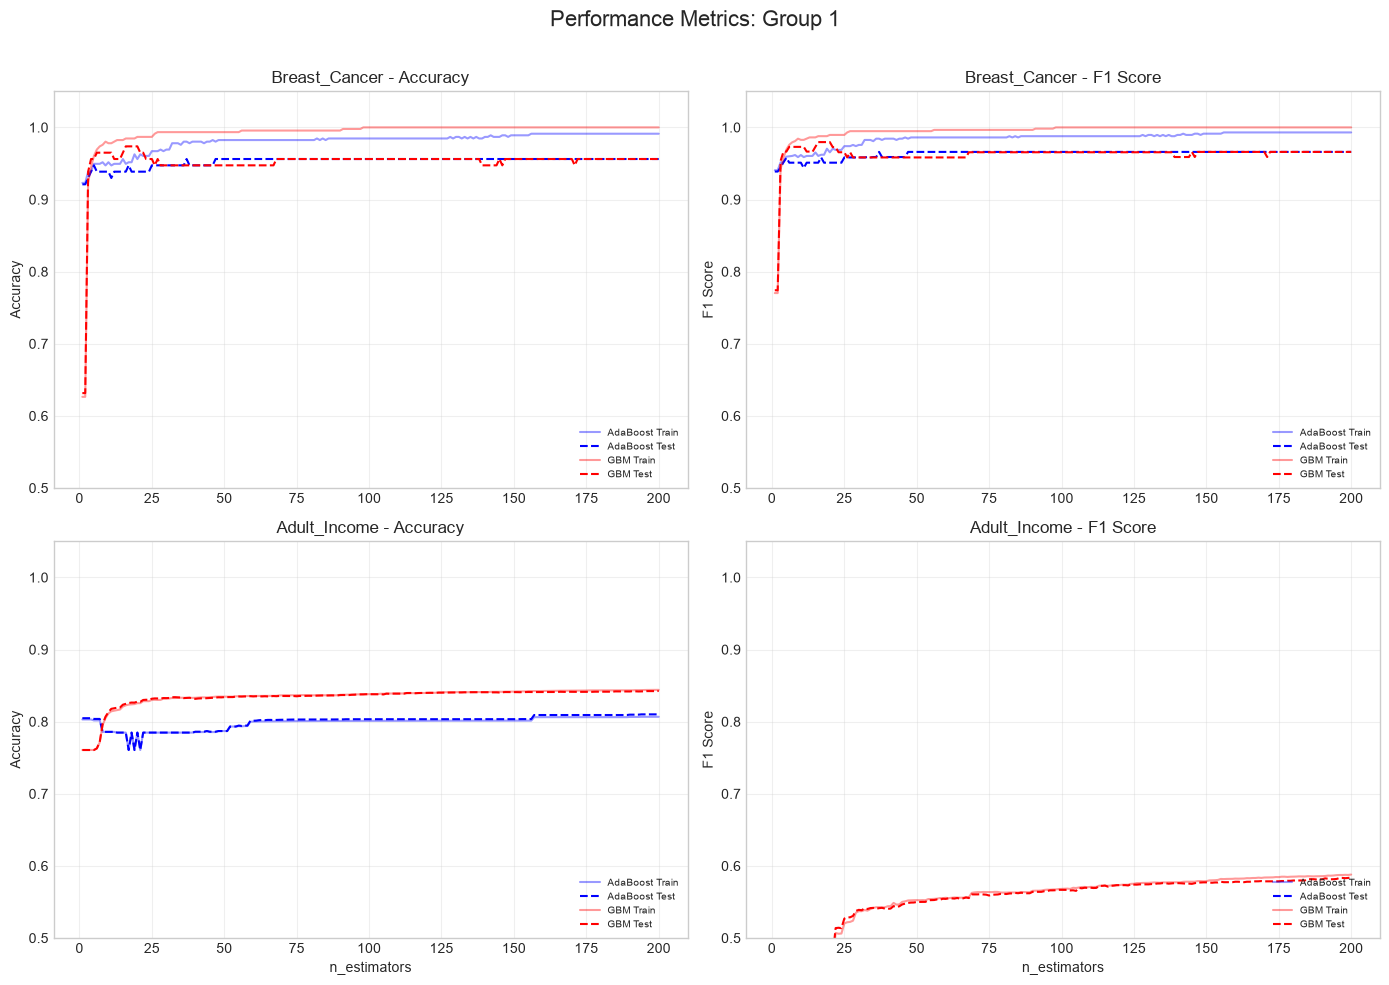

 Saved group plot: scaling_group_1.png


In [20]:
# Cell 8: Visualizations - Scaling Curves (Split into two figures)

if not combined_df.empty:
    datasets_list = combined_df["dataset"].unique()
    # Group datasets by your requirement
    group1 = ["Breast_Cancer", "Adult_Income"]
    group2 = ["Covertype", "MNIST"]

    for g_idx, group in enumerate([group1]):
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        fig.suptitle(f"Performance Metrics: Group {g_idx + 1}", fontsize=16)

        for idx, dataset in enumerate(group):
            ax_acc = axes[idx, 0]  # Accuracy column
            ax_f1 = axes[idx, 1]  # F1 column

            df_subset = combined_df[combined_df["dataset"] == dataset]
            ab_data = df_subset[df_subset["model"] == "AdaBoost"]
            gb_data = df_subset[df_subset["model"] == "Gradient Boosting"]

            # Plot Accuracy (Left Column)
            ax_acc.plot(
                ab_data["n_estimators"],
                ab_data["train_accuracy"],
                "b-",
                label="AdaBoost Train",
                alpha=0.4,
            )
            ax_acc.plot(
                ab_data["n_estimators"],
                ab_data["test_accuracy"],
                "b--",
                label="AdaBoost Test",
            )
            ax_acc.plot(
                gb_data["n_estimators"],
                gb_data["train_accuracy"],
                "r-",
                label="GBM Train",
                alpha=0.4,
            )
            ax_acc.plot(
                gb_data["n_estimators"],
                gb_data["test_accuracy"],
                "r--",
                label="GBM Test",
            )
            ax_acc.set_title(f"{dataset} - Accuracy")
            ax_acc.set_ylabel("Accuracy")
            ax_acc.grid(True, alpha=0.3)
            ax_acc.legend(loc="lower right", fontsize="x-small")
            ax_acc.set_ylim(0.5, 1.05)

            # Plot F1 Score (Right Column)
            ax_f1.plot(
                ab_data["n_estimators"],
                ab_data["train_f1"],
                "b-",
                label="AdaBoost Train",
                alpha=0.4,
            )
            ax_f1.plot(
                ab_data["n_estimators"],
                ab_data["test_f1"],
                "b--",
                label="AdaBoost Test",
            )
            ax_f1.plot(
                gb_data["n_estimators"],
                gb_data["train_f1"],
                "r-",
                label="GBM Train",
                alpha=0.4,
            )
            ax_f1.plot(
                gb_data["n_estimators"], gb_data["test_f1"], "r--", label="GBM Test"
            )
            ax_f1.set_title(f"{dataset} - F1 Score")
            ax_f1.set_ylabel("F1 Score")
            ax_f1.grid(True, alpha=0.3)
            ax_f1.legend(loc="lower right", fontsize="x-small")
            ax_f1.set_ylim(0.5, 1.05)

            if idx == 1:
                ax_acc.set_xlabel("n_estimators")
                ax_f1.set_xlabel("n_estimators")

        plt.tight_layout(rect=[0, 0, 1, 0.97])
        save_name = f"scaling_group_{g_idx + 1}.png"
        plt.savefig(os.path.join(FIGURES_DIR, save_name), dpi=150)
        plt.show()
        print(f" Saved group plot: {save_name}")
else:
    print(" No data to visualize. Run experiments first.")

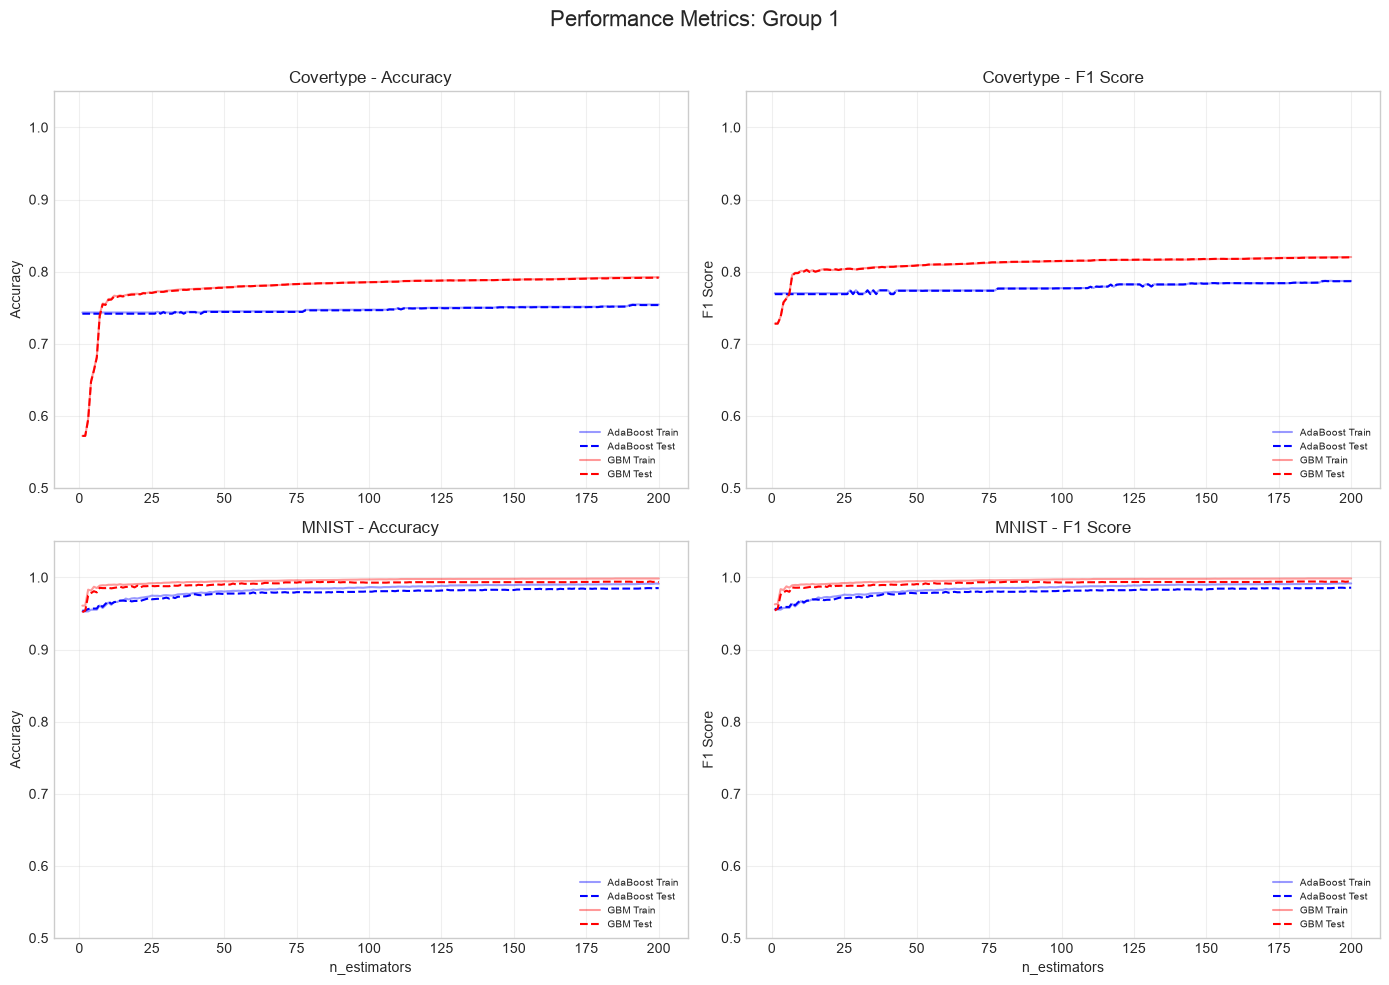

 Saved group plot: scaling_group_1.png


In [19]:
# Cell 8: Visualizations - Scaling Curves (Split into two figures)

if not combined_df.empty:
    datasets_list = combined_df["dataset"].unique()
    # Group datasets by your requirement
    group1 = ["Breast_Cancer", "Adult_Income"]
    group2 = ["Covertype", "MNIST"]

    for g_idx, group in enumerate([group2]):
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        fig.suptitle(f"Performance Metrics: Group {g_idx + 1}", fontsize=16)

        for idx, dataset in enumerate(group):
            ax_acc = axes[idx, 0]  # Accuracy column
            ax_f1 = axes[idx, 1]  # F1 column

            df_subset = combined_df[combined_df["dataset"] == dataset]
            ab_data = df_subset[df_subset["model"] == "AdaBoost"]
            gb_data = df_subset[df_subset["model"] == "Gradient Boosting"]

            # Plot Accuracy (Left Column)
            ax_acc.plot(
                ab_data["n_estimators"],
                ab_data["train_accuracy"],
                "b-",
                label="AdaBoost Train",
                alpha=0.4,
            )
            ax_acc.plot(
                ab_data["n_estimators"],
                ab_data["test_accuracy"],
                "b--",
                label="AdaBoost Test",
            )
            ax_acc.plot(
                gb_data["n_estimators"],
                gb_data["train_accuracy"],
                "r-",
                label="GBM Train",
                alpha=0.4,
            )
            ax_acc.plot(
                gb_data["n_estimators"],
                gb_data["test_accuracy"],
                "r--",
                label="GBM Test",
            )
            ax_acc.set_title(f"{dataset} - Accuracy")
            ax_acc.set_ylabel("Accuracy")
            ax_acc.grid(True, alpha=0.3)
            ax_acc.legend(loc="lower right", fontsize="x-small")
            ax_acc.set_ylim(0.5, 1.05)

            # Plot F1 Score (Right Column)
            ax_f1.plot(
                ab_data["n_estimators"],
                ab_data["train_f1"],
                "b-",
                label="AdaBoost Train",
                alpha=0.4,
            )
            ax_f1.plot(
                ab_data["n_estimators"],
                ab_data["test_f1"],
                "b--",
                label="AdaBoost Test",
            )
            ax_f1.plot(
                gb_data["n_estimators"],
                gb_data["train_f1"],
                "r-",
                label="GBM Train",
                alpha=0.4,
            )
            ax_f1.plot(
                gb_data["n_estimators"], gb_data["test_f1"], "r--", label="GBM Test"
            )
            ax_f1.set_title(f"{dataset} - F1 Score")
            ax_f1.set_ylabel("F1 Score")
            ax_f1.grid(True, alpha=0.3)
            ax_f1.legend(loc="lower right", fontsize="x-small")
            ax_f1.set_ylim(0.5, 1.05)

            if idx == 1:
                ax_acc.set_xlabel("n_estimators")
                ax_f1.set_xlabel("n_estimators")

        plt.tight_layout(rect=[0, 0, 1, 0.97])
        save_name = f"scaling_group_{g_idx + 1}.png"
        plt.savefig(os.path.join(FIGURES_DIR, save_name), dpi=150)
        plt.show()
        print(f" Saved group plot: {save_name}")
else:
    print(" No data to visualize. Run experiments first.")